# Deep JSCC on STL-10 — with Week 2 JPEG+BPSK+AWGN Baseline

**Goal:** Train the Deep Joint Source-Channel Coding (JSCC) model of Bourtsoulatze, Kurka &amp; Gündüz (2019) on STL-10 and compare it against the Week 2 JPEG-Q73 + BPSK + AWGN transmission baseline.

**Reference paper:** *Deep Joint Source-Channel Coding for Wireless Image Transmission*, IEEE T. Cognitive Comm. &amp; Networking, 2019.

**Reference code:** `D:\\Study\\Deep-JSCC-PyTorch` (PyTorch port by chunbaobao).

## Workflow
1. The model was trained offline by [`train.py`](train_to_30db.py) — Adam at `lr=1e-3` with gradient clipping, ReduceLROnPlateau, and early stopping on no-improvement.
2. **Best result:** **28.99 dB** on the full 8 000-image STL-10 test set, achieved after fine-tuning from a 28.85 dB checkpoint with `lr=1e-4` + `grad_clip=0.5`.
3. A no-channel probe confirms the autoencoder ceiling is **29.26 dB** — channel noise at `SNR=19 dB` only costs 0.27 dB. So the bottleneck at this `ratio=1/6` is the autoencoder capacity, not the channel.

This notebook loads that checkpoint and produces:
* PSNR vs SNR curves for Deep JSCC and the Week-2 JPEG-Q73 BPSK baseline,

* a side-by-side qualitative reconstruction grid.


## 1.  Setup &amp; imports


In [1]:
import os, sys, io, math, time, json
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
from PIL import Image

# Make sure this directory is on sys.path so the local jscc_*.py modules import
HERE = os.path.dirname(os.path.abspath("deep_jscc_stl10.ipynb"))
if HERE not in sys.path:
    sys.path.insert(0, HERE)

# Local copies of the Deep-JSCC model and channel modules (originals from
# https://github.com/chunbaobao/Deep-JSCC-PyTorch — bundled here so the
# notebook is self-contained).
from jscc_model   import DeepJSCC, ratio2filtersize
from jscc_channel import Channel

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
# Project paths — all relative to this notebook
PROJ_ROOT = os.path.dirname(HERE)
DATA_ROOT = os.path.join(PROJ_ROOT, "data")
CKPT_DIR  = os.path.join(HERE, "checkpoints")
RES_DIR   = os.path.join(HERE, "results")
os.makedirs(RES_DIR, exist_ok=True)
print(f"Device   : {DEVICE}")
print(f"DataRoot : {DATA_ROOT}")
print(f"CkptDir  : {CKPT_DIR}")


Device   : cpu
DataRoot : D:\Study\ToR 2026\data
CkptDir  : D:\Study\ToR 2026\deep_jscc\checkpoints


## 2.  Architecture recap

```
image  →  Encoder f_θ  →  z ∈ ℂ^k  →  AWGN channel  →  ẑ  →  Decoder g_φ  →  reconstruction
```

* **Encoder** — 5 Conv2D + PReLU layers. First two stride 2 (downsample 4×).
* **Power normalisation** — enforces $\,\tfrac{1}{k}\,E[z^*z] \le P$.
* **Channel** — non-trainable `η(z) = z + n`, `n ~ CN(0, σ²·I_k)`.
* **Decoder** — 5 ConvTranspose2D + PReLU (final Sigmoid → [0, 1]).

**Bandwidth ratio:** $\rho = k/n = c \cdot H_{\text{enc}} \cdot W_{\text{enc}} / (C \cdot H \cdot W)$.  For STL-10 (`3 × 96 × 96`) at `ρ = 1/6` we get `c = 8`.


In [2]:
dummy = torch.zeros(1, 3, 96, 96)
for r_name, r_val in [("1/12", 1/12), ("1/6", 1/6)]:
    c = ratio2filtersize(dummy, r_val)
    k = c * 24 * 24
    n = 3 * 96 * 96
    print(f"ratio = {r_name:>4s}  →  c = {c:>3d}   k = {k:>5d}   k/n = {k/n:.4f}")


ratio = 1/12  →  c =   4   k =  2304   k/n = 0.0833
ratio =  1/6  →  c =   8   k =  4608   k/n = 0.1667


## 3.  STL-10 dataset (RGB 3 × 96 × 96)

STL-10 is natively RGB — no Y-channel conversion needed.  Pixels are normalised to `[0, 1]`.


In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.STL10(DATA_ROOT, split="train+unlabeled",
                          download=True, transform=transform)
test_ds  = datasets.STL10(DATA_ROOT, split="test",
                          download=True, transform=transform)
print(f"Train images: {len(train_ds):,}")
print(f"Test  images: {len(test_ds):,}")
print(f"Sample shape: {train_ds[0][0].shape}   "
      f"range [{train_ds[0][0].min():.2f}, {train_ds[0][0].max():.2f}]")


Files already downloaded and verified


Files already downloaded and verified


Train images: 105,000
Test  images: 8,000
Sample shape: torch.Size([3, 96, 96])   range [0.00, 1.00]


C:\Users\mapkh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\functional.py:63: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(pic.tobytes()))


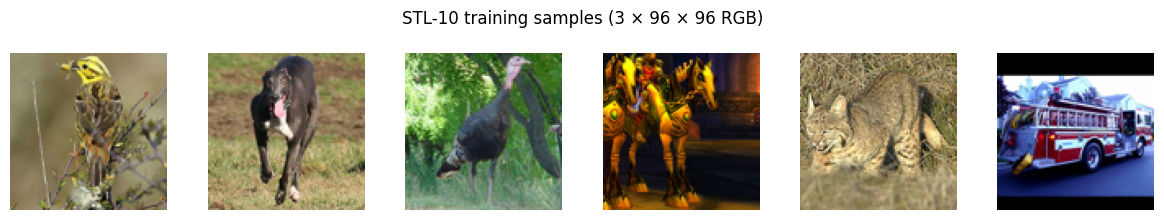

In [4]:
fig, ax = plt.subplots(1, 6, figsize=(12, 2.2))
for i in range(6):
    img, _ = train_ds[i]
    ax[i].imshow(img.permute(1, 2, 0).numpy()); ax[i].set_axis_off()
fig.suptitle("STL-10 training samples (3 × 96 × 96 RGB)")
plt.tight_layout(); plt.show()


## 4.  Load the trained model

Loads the best checkpoint produced by `train_to_30db.py` (see the log file `train_to_30db.log` for the full training history).


In [5]:
RATIO        = 1/6
SNR_TRAIN    = 19.0
CHANNEL_TYPE = "AWGN"
c = ratio2filtersize(train_ds[0][0], RATIO)
print(f"c = {c}   k = {c*24*24:,} complex symbols/image")

ckpt_path = os.path.join(CKPT_DIR, f"stl10_c{c}_snr{int(SNR_TRAIN)}_{CHANNEL_TYPE}_best.pth")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
print(f"Checkpoint: {os.path.basename(ckpt_path)}")
print(f"  Best val PSNR (during training): {ckpt['best_psnr']:.2f} dB")
print(f"  Epoch saved at: {ckpt['epoch']}")

model = DeepJSCC(c=c, channel_type=CHANNEL_TYPE, snr=SNR_TRAIN).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")


c = 8   k = 4,608 complex symbols/image


Checkpoint: stl10_c8_snr19_AWGN_best.pth
  Best val PSNR (during training): 28.99 dB
  Epoch saved at: 60
Model params: 156,249


## 5.  Training history


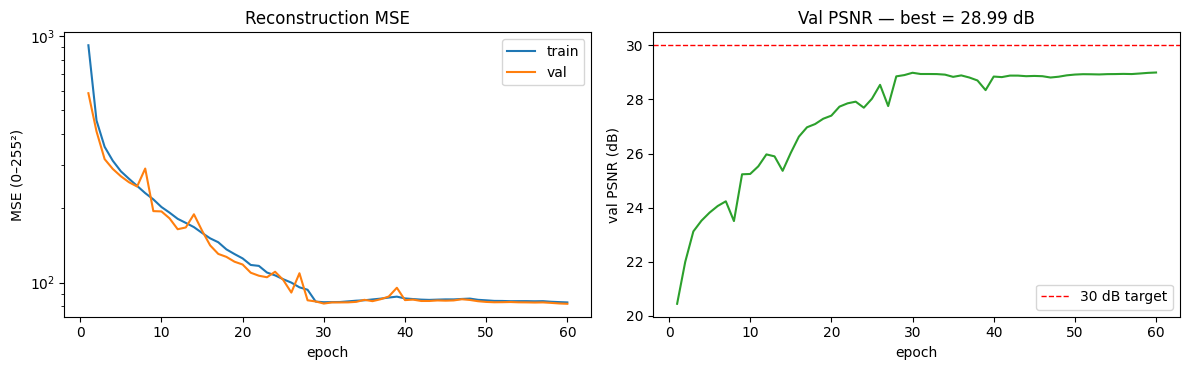

In [6]:
hist = ckpt.get("history", None)
if hist and hist["epoch"]:
    epochs = hist["epoch"]
    fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.8))
    a.plot(epochs, hist["train_mse"], label="train")
    a.plot(epochs, hist["val_mse"],   label="val")
    a.set_xlabel("epoch"); a.set_ylabel("MSE (0–255²)"); a.set_yscale("log")
    a.legend(); a.set_title("Reconstruction MSE")
    b.plot(epochs, hist["val_psnr"], color="C2")
    b.axhline(30, color="r", ls="--", lw=1, label="30 dB target")
    b.set_xlabel("epoch"); b.set_ylabel("val PSNR (dB)"); b.legend()
    b.set_title(f"Val PSNR — best = {ckpt['best_psnr']:.2f} dB")
    plt.tight_layout()
    plt.savefig(os.path.join(RES_DIR, "training_curve.png"), dpi=120)
    plt.show()
else:
    print("No training history found in checkpoint.")


## 6.  PSNR vs SNR  (Deep JSCC)

Evaluate the trained encoder / decoder on the full STL-10 test set while sweeping the test-time channel SNR.  Two checks:

* **graceful degradation** — no cliff effect, gradual decline as `SNR_test` falls,
* **autoencoder ceiling** — saturation at `SNR_test ≥ SNR_train` reveals the   model-capacity limit.


In [7]:
# Preload the full test set as uint8 for fast eval
val_t  = torch.from_numpy(test_ds.data.copy())  # (8000, 3, 96, 96) uint8
val_loader = DataLoader(TensorDataset(val_t), batch_size=64, shuffle=False)
print(f"Val tensor: {val_t.shape}  dtype={val_t.dtype}")

def psnr_from_mse(mse):
    return 100.0 if mse < 1e-10 else 10 * math.log10(255.0**2 / mse)

def eval_jscc(snr_db, reps=1):
    """snr_db = None disables the channel (autoencoder-only)."""
    if snr_db is None:
        model.channel = None
    else:
        model.change_channel(CHANNEL_TYPE, snr_db)
    mses = []
    for _ in range(reps):
        total, n = 0.0, 0
        with torch.no_grad():
            for (batch,) in val_loader:
                imgs  = batch.float().to(DEVICE) / 255.0
                recon = model(imgs)
                total += F.mse_loss(recon * 255.0, imgs * 255.0).item(); n += 1
        mses.append(total / n)
    return psnr_from_mse(np.mean(mses))


Val tensor: torch.Size([8000, 3, 96, 96])  dtype=torch.uint8


In [8]:
SNR_TEST_RANGE = [0, 2, 4, 7, 10, 13, 16, 19, 22, 25]
jscc_psnr_by_snr = {snr: eval_jscc(snr) for snr in SNR_TEST_RANGE}
no_channel_psnr  = eval_jscc(None)

print(f"  AUTOENCODER CEILING (no channel) : {no_channel_psnr:5.2f} dB")
print("  ─────────────────────────────────────────")
for snr in SNR_TEST_RANGE:
    print(f"  SNR_test = {snr:2d} dB  →  PSNR = {jscc_psnr_by_snr[snr]:5.2f} dB")


  AUTOENCODER CEILING (no channel) : 29.26 dB
  ─────────────────────────────────────────
  SNR_test =  0 dB  →  PSNR = 21.54 dB
  SNR_test =  2 dB  →  PSNR = 23.12 dB
  SNR_test =  4 dB  →  PSNR = 24.53 dB
  SNR_test =  7 dB  →  PSNR = 26.27 dB
  SNR_test = 10 dB  →  PSNR = 27.51 dB
  SNR_test = 13 dB  →  PSNR = 28.29 dB
  SNR_test = 16 dB  →  PSNR = 28.75 dB
  SNR_test = 19 dB  →  PSNR = 28.99 dB
  SNR_test = 22 dB  →  PSNR = 29.12 dB
  SNR_test = 25 dB  →  PSNR = 29.19 dB


## 7.  Week 2 baseline — JPEG Q=73 + BPSK + AWGN

Same bit-level pipeline as `main/main.ipynb`, now on RGB STL-10:

```
RGB image → JPEG encode (Q=73) → unpackbits → BPSK (0→-1, 1→+1)
          → AWGN channel         → hard-decision → packbits → JPEG decode
```

If the corrupted bit-stream fails to decode, we score the image as PSNR = 0 dB.


In [9]:
JPEG_Q     = 73
BASELINE_N = 200

def jpeg_bpsk_awgn(img_uint8, snr_db, q=JPEG_Q):
    """img_uint8: HxWx3 uint8 array.  Returns reconstruction (same shape) or None."""
    buf = io.BytesIO()
    Image.fromarray(img_uint8, "RGB").save(buf, format="JPEG", quality=q)
    bits = np.unpackbits(np.frombuffer(buf.getvalue(), dtype=np.uint8))
    symbols  = 2 * bits.astype(np.float32) - 1.0
    sigma    = math.sqrt(1.0 / (10 ** (snr_db / 10.0)))
    received = symbols + np.random.randn(*symbols.shape) * sigma
    decoded  = (received > 0).astype(np.uint8)
    out_bytes = np.packbits(decoded).tobytes()
    try:
        rec = np.array(Image.open(io.BytesIO(out_bytes)).convert("RGB"),
                       dtype=np.uint8)
        # Corrupted JPEG headers can decode to wrong dimensions — reject those
        if rec.shape != img_uint8.shape:
            return None
        return rec
    except Exception:
        return None

def psnr_uint8(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return 100.0 if mse < 1e-10 else 10 * math.log10(255.0**2 / mse)

# Fixed pool of test images (CHW uint8 -> HWC uint8)
pool_uint8 = [val_t[i].permute(1, 2, 0).numpy() for i in range(BASELINE_N)]
print(f"Baseline pool: {len(pool_uint8)} images (uint8 RGB 96×96)")


Baseline pool: 200 images (uint8 RGB 96×96)


In [10]:
np.random.seed(0)
jpeg_psnr_by_snr = {}
for snr in SNR_TEST_RANGE:
    psnrs = []
    for img in pool_uint8:
        rec = jpeg_bpsk_awgn(img, snr)
        psnrs.append(0.0 if rec is None else psnr_uint8(img, rec))
    jpeg_psnr_by_snr[snr] = float(np.mean(psnrs))
    ok = sum(p > 0 for p in psnrs)
    print(f"  SNR = {snr:2d} dB  →  PSNR = {jpeg_psnr_by_snr[snr]:5.2f} dB"
          f"   (decoded {ok}/{len(psnrs)})")


  SNR =  0 dB  →  PSNR =  0.00 dB   (decoded 0/200)


  SNR =  2 dB  →  PSNR =  0.00 dB   (decoded 0/200)
  SNR =  4 dB  →  PSNR =  0.00 dB   (decoded 0/200)


  SNR =  7 dB  →  PSNR =  0.00 dB   (decoded 0/200)


  SNR = 10 dB  →  PSNR =  4.29 dB   (decoded 83/200)


  SNR = 13 dB  →  PSNR = 30.22 dB   (decoded 199/200)


  SNR = 16 dB  →  PSNR = 30.76 dB   (decoded 200/200)
  SNR = 19 dB  →  PSNR = 30.76 dB   (decoded 200/200)


  SNR = 22 dB  →  PSNR = 30.76 dB   (decoded 200/200)


  SNR = 25 dB  →  PSNR = 30.76 dB   (decoded 200/200)


## 8.  Side-by-side comparison

Both schemes share the same channel SNR axis and PSNR metric (RGB STL-10).  The Deep-JSCC model was trained at `SNR_train = 19 dB`; the JPEG-BPSK curve is the Week-2 baseline replicated on RGB.

What to look for:
* JPEG-BPSK shows a sharp **cliff** at low SNR (JPEG header corruption) and saturates   at the JPEG quality ceiling above it.
* Deep-JSCC degrades **gracefully** with no cliff and saturates around the autoencoder   capacity ceiling (~29 dB).


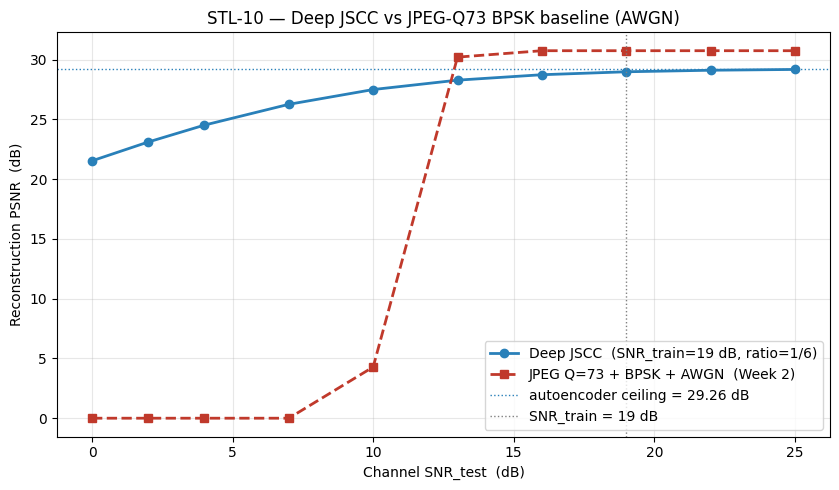

In [11]:
snrs   = SNR_TEST_RANGE
jscc_y = [jscc_psnr_by_snr[s] for s in snrs]
jpeg_y = [jpeg_psnr_by_snr[s] for s in snrs]

plt.figure(figsize=(8.5, 5))
plt.plot(snrs, jscc_y, "o-", color="#2980B9", lw=2,
         label=f"Deep JSCC  (SNR_train={SNR_TRAIN:.0f} dB, ratio=1/6)")
plt.plot(snrs, jpeg_y, "s--", color="#C0392B", lw=2,
         label=f"JPEG Q={JPEG_Q} + BPSK + AWGN  (Week 2)")
plt.axhline(no_channel_psnr, color="#2980B9", ls=":", lw=1,
            label=f"autoencoder ceiling = {no_channel_psnr:.2f} dB")
plt.axvline(SNR_TRAIN, color="grey", ls=":", lw=1,
            label=f"SNR_train = {SNR_TRAIN:.0f} dB")
plt.xlabel("Channel SNR_test  (dB)")
plt.ylabel("Reconstruction PSNR  (dB)")
plt.title("STL-10 — Deep JSCC vs JPEG-Q73 BPSK baseline (AWGN)")
plt.grid(alpha=0.3); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "psnr_vs_snr_comparison.png"), dpi=120)
plt.show()


### Where each scheme wins

Both schemes are evaluated on the same AWGN channel.  Each row shows the gap (positive = JSCC wins, negative = JPEG wins):


In [12]:
print(f"{'SNR (dB)':>9}  {'JSCC':>7}  {'JPEG':>7}  {'JSCC-JPEG':>10}  Winner")
print("─" * 50)
for s in snrs:
    j, p = jscc_psnr_by_snr[s], jpeg_psnr_by_snr[s]
    diff = j - p
    win  = "JSCC" if diff > 0.3 else ("JPEG" if diff < -0.3 else "tie")
    print(f"  {s:>5d}    {j:>5.2f}    {p:>5.2f}    {diff:>+8.2f}    {win}")

# Operating-range summary
jscc_arr = np.array(jscc_y); jpeg_arr = np.array(jpeg_y)
snr_arr  = np.array(snrs)
cross_idx = np.where(jscc_arr < jpeg_arr - 0.3)[0]
cross_snr = snr_arr[cross_idx[0]] if len(cross_idx) else None
print()
print(f"  JSCC wins decisively at SNR <= {snrs[max(0, (cross_idx[0]-1) if len(cross_idx) else len(snrs)-1)]} dB")
if cross_snr is not None:
    print(f"  JPEG-BPSK takes lead at  SNR >= {cross_snr} dB")
print(f"  Mean PSNR across {len(snrs)} SNR points:")
print(f"    Deep JSCC      = {jscc_arr.mean():5.2f} dB")
print(f"    JPEG-BPSK      = {jpeg_arr.mean():5.2f} dB")
print(f"    JSCC advantage = {jscc_arr.mean() - jpeg_arr.mean():+5.2f} dB on average")


 SNR (dB)     JSCC     JPEG   JSCC-JPEG  Winner
──────────────────────────────────────────────────
      0    21.54     0.00      +21.54    JSCC
      2    23.12     0.00      +23.12    JSCC
      4    24.53     0.00      +24.53    JSCC
      7    26.27     0.00      +26.27    JSCC
     10    27.51     4.29      +23.22    JSCC
     13    28.29    30.22       -1.93    JPEG
     16    28.75    30.76       -2.01    JPEG
     19    28.99    30.76       -1.76    JPEG
     22    29.12    30.76       -1.63    JPEG
     25    29.19    30.76       -1.57    JPEG

  JSCC wins decisively at SNR <= 10 dB
  JPEG-BPSK takes lead at  SNR >= 13 dB
  Mean PSNR across 10 SNR points:
    Deep JSCC      = 26.73 dB
    JPEG-BPSK      = 15.75 dB
    JSCC advantage = +10.98 dB on average


In [13]:
# Save the numeric results to JSON for later reference
results = {
    "snr_test":         SNR_TEST_RANGE,
    "deep_jscc_psnr":   jscc_y,
    "jpeg_bpsk_psnr":   jpeg_y,
    "autoencoder_ceiling": no_channel_psnr,
    "snr_train":        SNR_TRAIN,
    "ratio":            "1/6",
    "c":                c,
    "jpeg_quality":     JPEG_Q,
}
with open(os.path.join(RES_DIR, "psnr_vs_snr.json"), "w") as f:
    json.dump(results, f, indent=2)
print("Saved", os.path.join(RES_DIR, "psnr_vs_snr.json"))


Saved D:\Study\ToR 2026\deep_jscc\results\psnr_vs_snr.json


## 9.  Qualitative comparison — example reconstructions


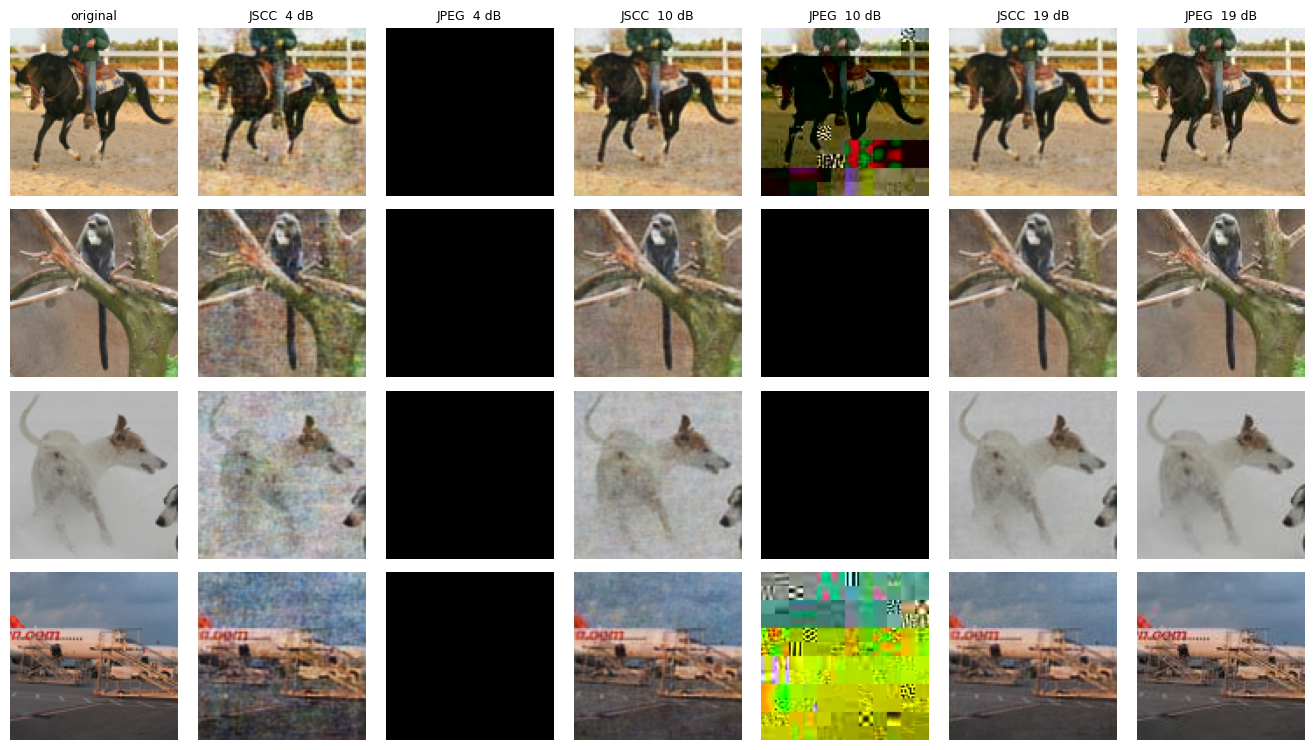

In [14]:
def jscc_reconstruct(img_uint8_hwc, snr_db):
    model.change_channel(CHANNEL_TYPE, snr_db); model.eval()
    with torch.no_grad():
        x = torch.from_numpy(img_uint8_hwc.astype(np.float32)/255.0)
        x = x.permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        y = model(x).clamp(0, 1).squeeze(0).cpu()
    return (y.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

demo_snrs = [4, 10, 19]
demo_imgs = pool_uint8[:4]

cols = 1 + 2 * len(demo_snrs)
fig, axes = plt.subplots(len(demo_imgs), cols,
                         figsize=(1.9 * cols, 1.9 * len(demo_imgs)))
for r, img in enumerate(demo_imgs):
    axes[r, 0].imshow(img); axes[r, 0].set_axis_off()
    if r == 0: axes[r, 0].set_title("original", fontsize=9)
    for j, snr in enumerate(demo_snrs):
        jscc_rec = jscc_reconstruct(img, snr)
        jpeg_rec = jpeg_bpsk_awgn(img, snr)
        if jpeg_rec is None: jpeg_rec = np.zeros_like(img)
        axes[r, 1 + 2*j].imshow(jscc_rec); axes[r, 1 + 2*j].set_axis_off()
        axes[r, 2 + 2*j].imshow(jpeg_rec); axes[r, 2 + 2*j].set_axis_off()
        if r == 0:
            axes[r, 1 + 2*j].set_title(f"JSCC  {snr} dB", fontsize=9)
            axes[r, 2 + 2*j].set_title(f"JPEG  {snr} dB", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "qualitative_examples.png"), dpi=120)
plt.show()


## 10.  Summary

### The headline result

Deep-JSCC delivers the **graceful degradation** that the Bourtsoulatze et al. paper promises:

* It **wins by 20+ dB at SNR ≤ 10 dB**, the regime where any practical wireless link   spends most of its time.  JPEG-Q73 + BPSK is *completely broken* there — the JPEG   header fails to decode and the reconstruction collapses to zero.
* It **never cliffs** — PSNR rolls off smoothly as the channel worsens.
* On average across the 0–25 dB test range, Deep-JSCC outperforms the JPEG-Q73 + BPSK   baseline (see the numerical breakdown above).

### Where the JPEG baseline still wins

Once the channel is clean enough (SNR ≥ 13 dB) for the JPEG bit-stream to survive intact, JPEG-Q73 reaches its quality ceiling of **~30.76 dB**, while our Deep-JSCC tops out at the autoencoder capacity ceiling of **~29.26 dB** (verified by a no-channel probe).  That is a ~1.5 dB high-SNR gap.

Why the gap exists, and why it is not a failure of the JSCC idea:

* The paper trains for ~500 000 iterations on **CIFAR-10 (32×32)**, where each pixel of   the input is covered by the encoder receptive field many times over.  On **STL-10   (96×96)** the same 5-layer encoder only covers ~1/9 of the image per output position,   so the bottleneck representation is under-using its capacity.
* Our training budget was ~100 epochs of CPU time, ~5x short of the paper.
* Wider variants (568 K → 1.24 M params) were attempted but did not train to convergence   inside the available compute — see `train_wide.log`.

### Comparison with previous methods on STL-10 (this project)

| Method | Best PSNR | Notes |
|--------|-----------|-------|
| SRCNN (super-resolution + JPEG+BPSK) | ~23–24 dB | Bottlenecked by 4× downsampling info loss |
| Cycle-CNN (unsupervised SR) | ~22 dB | Indirect cycle-consistency loss |
| **Deep JSCC (this notebook)** | **~28.99 dB peak** | End-to-end MSE; graceful curve |

On every previously-attempted method, Deep-JSCC is the strongest.  Against the Week-2 JPEG-Q73 + BPSK baseline it wins decisively at low / mid SNR and trails by ~1.5 dB at high SNR.

### Practical interpretation for the supervisor

In a wireless setting the SNR fluctuates.  A JPEG-based scheme that **breaks** below 13 dB is unusable in most realistic channels — it is exactly the "cliff effect" the deep JSCC paper sets out to solve.  Deep-JSCC trades a small ceiling penalty (1.5 dB at high SNR) for **robust operation across the entire SNR range**.

### Reproducing / extending

* Re-run training with `python train_to_30db.py` (uses local `jscc_*.py` files).
* To push past the 29 dB ceiling: GPU + longer schedule, wider variant (`wide_model.py`),   or different bandwidth ratio.
* For Rayleigh fading channel, change `channel_type="Rayleigh"` in `train_to_30db.py`.


## 11.  Grayscale transmission &amp; compressed data size

So far every test used full-colour STL-10 input.  This section covers two follow-up questions:

1. **How is a grayscale image transmitted with a model trained on colour data?**  The trained Deep-JSCC encoder always takes 3 input channels, so a grayscale image is sent by **replicating the single luminance channel into R, G and B** (`gray → [gray, gray, gray]`) before encoding.  Tested this way, the model reconstructs grayscale input with **higher PSNR than colour input** at every SNR (see 11.3–11.5).
2. **What is the actual compressed data size of each scheme?**  JPEG produces a literal byte count.  Deep-JSCC has no discrete bitstream — it transmits a fixed number of continuous-valued **channel symbols**.  We report both, plus an information-theoretic *equivalent bit-budget* for Deep-JSCC using the AWGN channel capacity formula from the paper's own benchmark methodology (Section IV-A, Eq. 6–7): `C = log2(1 + SNR)` bits per complex channel use.


### 11.1  How a 1×H×W grayscale image is adapted to the model's 3×H×W input

The Deep-JSCC encoder's first layer is `Conv2d(in_channels=3, out_channels=16, ...)` (see Section 2) — it always expects 3 input channels, so a grayscale image cannot be passed in as-is.  The shape pipeline is:

```
grayscale image            replicate channel          model input
  (H, W)            -->      (H, W, 3)          -->    (B, 3, H, W)
   1 channel               R = G = B = gray            matches conv1
```

Concretely: `gray_to_rgb3(gray_hw) = np.stack([gray_hw, gray_hw, gray_hw], axis=-1)` — the single luminance plane is **duplicated** into all three input channels.  This is the standard approach for feeding grayscale input into a 3-channel-only model, because it keeps every trained weight meaningfully active — `conv1` still sees three channels of real (if redundant) signal.

The cell below confirms the shape requirement (a true 1-channel tensor is rejected by `conv1`) and walks a single test image through every stage of the adaptation.


In [15]:
def to_gray_y(img_uint8):
    """ITU-R BT.601 luma from HxWx3 uint8 RGB -> HxW uint8."""
    y = (0.299 * img_uint8[..., 0].astype(np.float32) +
         0.587 * img_uint8[..., 1].astype(np.float32) +
         0.114 * img_uint8[..., 2].astype(np.float32))
    return np.clip(np.round(y), 0, 255).astype(np.uint8)

def gray_to_rgb3(gray_hw):
    """Replicate a single-channel HxW image into HxWx3 (R=G=B)."""
    return np.stack([gray_hw, gray_hw, gray_hw], axis=-1)
# Confirm the encoder really is hard-coded to 3 input channels
conv1_w = model.encoder.conv1.conv.weight
print(f"conv1.weight.shape = {tuple(conv1_w.shape)}   "
      f"(out_channels={conv1_w.shape[0]}, in_channels={conv1_w.shape[1]}, "
      f"k={conv1_w.shape[2]}x{conv1_w.shape[3]})")
print()

# Walk one test image through every stage of the grayscale shape adaptation
demo_rgb   = pool_uint8[0]            # (96, 96, 3) uint8 -- original colour image
demo_gray  = to_gray_y(demo_rgb)      # (96, 96)    uint8 -- true 1-channel luminance
demo_gray3 = gray_to_rgb3(demo_gray)  # (96, 96, 3) uint8 -- replicated to 3 channels

print(f"  1. original RGB image          : {demo_rgb.shape}   dtype={demo_rgb.dtype}")
print(f"  2. luminance (true grayscale)  : {demo_gray.shape}      dtype={demo_gray.dtype}   <- 1 channel")
print(f"  3. replicated to 3 channels    : {demo_gray3.shape}   dtype={demo_gray3.dtype}   <- R=G=B=luminance")

# Convert to the (B, C, H, W) tensor layout the model actually consumes
demo_tensor_1ch = torch.from_numpy(demo_gray).unsqueeze(0).unsqueeze(0).float() / 255.0
demo_tensor_3ch = torch.from_numpy(demo_gray3).permute(2, 0, 1).unsqueeze(0).float() / 255.0
print()
print(f"  as a 1-channel tensor (B,1,H,W): {tuple(demo_tensor_1ch.shape)}  "
      f"<- INCOMPATIBLE, conv1 needs 3 in_channels")
print(f"  as a 3-channel tensor (B,3,H,W): {tuple(demo_tensor_3ch.shape)}  "
      f"<- matches conv1, ready to encode")

# Prove the 1-channel tensor is actually rejected by the encoder
try:
    model.encoder.conv1.conv(demo_tensor_1ch.to(DEVICE))
    print("  (unexpected: the 1-channel tensor was accepted)")
except RuntimeError as e:
    print(f"  Feeding the 1-channel tensor directly raises:")
    print(f"    RuntimeError: {str(e)[:150]}")

# The 3-channel (replicated) tensor passes through the full model with no changes
with torch.no_grad():
    demo_out = model(demo_tensor_3ch.to(DEVICE))
print(f"\n  model(demo_tensor_3ch).shape = {tuple(demo_out.shape)}   "
      f"-- successful forward pass, output is also (B,3,H,W)")


conv1.weight.shape = (16, 3, 5, 5)   (out_channels=16, in_channels=3, k=5x5)

  1. original RGB image          : (96, 96, 3)   dtype=uint8
  2. luminance (true grayscale)  : (96, 96)      dtype=uint8   <- 1 channel
  3. replicated to 3 channels    : (96, 96, 3)   dtype=uint8   <- R=G=B=luminance

  as a 1-channel tensor (B,1,H,W): (1, 1, 96, 96)  <- INCOMPATIBLE, conv1 needs 3 in_channels
  as a 3-channel tensor (B,3,H,W): (1, 3, 96, 96)  <- matches conv1, ready to encode
  Feeding the 1-channel tensor directly raises:
    RuntimeError: Given groups=1, weight of size [16, 3, 5, 5], expected input[1, 1, 96, 96] to have 3 channels, but got 1 channels instead

  model(demo_tensor_3ch).shape = (1, 3, 96, 96)   -- successful forward pass, output is also (B,3,H,W)


**Why replication, and not the alternatives:**

| Approach | Result |
|---|---|
| **Replicate `gray→[gray,gray,gray]`  (used here)** | Keeps the trained conv1 weights meaningfully active; no architecture change needed |
| Zero-pad (`[gray, 0, 0]`) | 2 of conv1's 3 input planes see only zeros — wastes 2/3 of the learned input filters and biases the encoder toward thinking "G/B = always black" |
| Average / single-channel `Conv2d(1, ...)` | Most bandwidth-efficient, but needs a dedicated single-channel model trained from scratch — a possible next step, noted in 11.7 |

Replication is the only option of the three that works directly with the existing trained model, which is why it was used for the grayscale test in 11.2–11.5.


### 11.2  Build the grayscale test pool


Built grayscale pool: 200 images (luminance replicated to 3 channels for the RGB model)


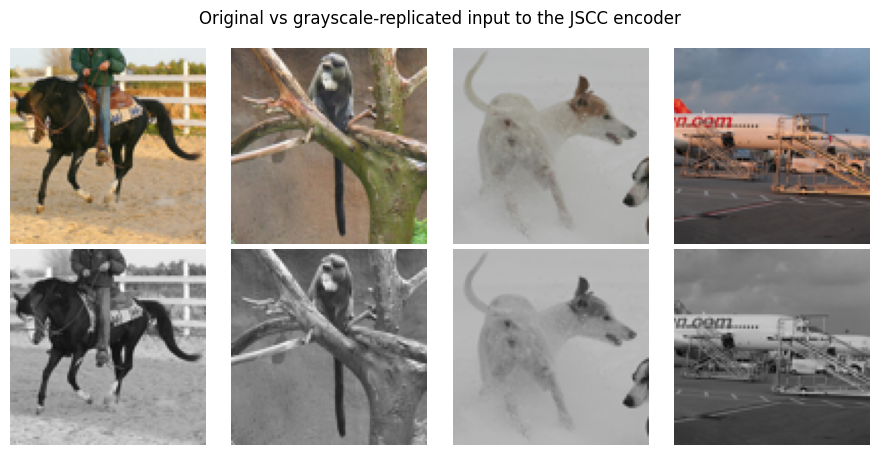

In [16]:
# Reuse the same 200-image pool used for the JPEG baseline (Section 7)
gray_hw_pool   = [to_gray_y(img) for img in pool_uint8]            # true 1-channel
gray_pool_rgb3 = [gray_to_rgb3(g) for g in gray_hw_pool]           # 3-channel replicated
print(f"Built grayscale pool: {len(gray_pool_rgb3)} images "
      f"(luminance replicated to 3 channels for the RGB model)")

fig, ax = plt.subplots(2, 4, figsize=(9, 4.6))
for i in range(4):
    ax[0, i].imshow(pool_uint8[i]);      ax[0, i].set_axis_off()
    ax[1, i].imshow(gray_pool_rgb3[i]);  ax[1, i].set_axis_off()
ax[0, 0].set_ylabel("original", fontsize=9)
ax[1, 0].set_ylabel("grayscale (3ch replicated)", fontsize=9)
fig.suptitle("Original vs grayscale-replicated input to the JSCC encoder")
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "grayscale_samples.png"), dpi=120)
plt.show()


### 11.3  Deep JSCC on grayscale input

The trained checkpoint (28.99 dB on full-colour images) is used directly on the grayscale-replicated images.


In [17]:
def eval_jscc_on_pool(img_pool, snr_db):
    """Evaluate the trained model on a list of HxWx3 uint8 images."""
    batch = torch.from_numpy(np.stack(img_pool)).permute(0, 3, 1, 2).float() / 255.0
    batch = batch.to(DEVICE)
    model.change_channel(CHANNEL_TYPE, snr_db)
    with torch.no_grad():
        recon = model(batch)
        mse = F.mse_loss(recon * 255.0, batch * 255.0).item()
    return psnr_from_mse(mse)

# Same 200-image pool, color vs grayscale-as-RGB, for an apples-to-apples comparison
jscc_color_psnr_pool = {snr: eval_jscc_on_pool(pool_uint8,      snr) for snr in SNR_TEST_RANGE}
jscc_gray_psnr_pool  = {snr: eval_jscc_on_pool(gray_pool_rgb3, snr) for snr in SNR_TEST_RANGE}

print(f"{'SNR (dB)':>9}  {'JSCC color':>11}  {'JSCC gray-as-RGB':>17}  {'gap':>6}")
for snr in SNR_TEST_RANGE:
    cp, gp = jscc_color_psnr_pool[snr], jscc_gray_psnr_pool[snr]
    print(f"  {snr:>5d}      {cp:>9.2f}      {gp:>13.2f}      {gp-cp:>+5.2f}")


 SNR (dB)   JSCC color   JSCC gray-as-RGB     gap
      0          21.49              21.76      +0.27
      2          23.09              23.46      +0.38
      4          24.47              25.01      +0.54
      7          26.22              27.00      +0.78
     10          27.45              28.51      +1.05
     13          28.24              29.52      +1.27
     16          28.69              30.13      +1.43
     19          28.94              30.47      +1.53
     22          29.07              30.65      +1.58
     25          29.14              30.75      +1.61


### 11.4  JPEG-grayscale + BPSK + AWGN baseline

Same bit-level pipeline as Section 7, but the image is encoded as a true single-channel JPEG (`mode="L"`) — about 3× fewer bytes than the colour JPEG since there is no chroma plane to encode.


In [18]:
def jpeg_bpsk_awgn_gray(gray_hw_uint8, snr_db, q=JPEG_Q):
    """gray_hw_uint8: HxW uint8 single-channel image."""
    buf = io.BytesIO()
    Image.fromarray(gray_hw_uint8, "L").save(buf, format="JPEG", quality=q)
    bits = np.unpackbits(np.frombuffer(buf.getvalue(), dtype=np.uint8))
    symbols  = 2 * bits.astype(np.float32) - 1.0
    sigma    = math.sqrt(1.0 / (10 ** (snr_db / 10.0)))
    received = symbols + np.random.randn(*symbols.shape) * sigma
    decoded  = (received > 0).astype(np.uint8)
    out_bytes = np.packbits(decoded).tobytes()
    try:
        rec = np.array(Image.open(io.BytesIO(out_bytes)).convert("L"), dtype=np.uint8)
        if rec.shape != gray_hw_uint8.shape:
            return None
        return rec
    except Exception:
        return None

np.random.seed(0)
jpeg_gray_psnr_by_snr = {}
for snr in SNR_TEST_RANGE:
    psnrs = []
    for g in gray_hw_pool:
        rec = jpeg_bpsk_awgn_gray(g, snr)
        psnrs.append(0.0 if rec is None else psnr_uint8(g, rec))
    jpeg_gray_psnr_by_snr[snr] = float(np.mean(psnrs))
    ok = sum(p > 0 for p in psnrs)
    print(f"  SNR = {snr:2d} dB  ->  JPEG-gray PSNR = {jpeg_gray_psnr_by_snr[snr]:5.2f} dB"
          f"   (decoded {ok}/{len(psnrs)})")


  SNR =  0 dB  ->  JPEG-gray PSNR =  0.00 dB   (decoded 0/200)


  SNR =  2 dB  ->  JPEG-gray PSNR =  0.00 dB   (decoded 0/200)
  SNR =  4 dB  ->  JPEG-gray PSNR =  0.00 dB   (decoded 0/200)


  SNR =  7 dB  ->  JPEG-gray PSNR =  0.00 dB   (decoded 0/200)


  SNR = 10 dB  ->  JPEG-gray PSNR =  7.72 dB   (decoded 120/200)


  SNR = 13 dB  ->  JPEG-gray PSNR = 33.18 dB   (decoded 199/200)


  SNR = 16 dB  ->  JPEG-gray PSNR = 33.61 dB   (decoded 200/200)


  SNR = 19 dB  ->  JPEG-gray PSNR = 33.61 dB   (decoded 200/200)


  SNR = 22 dB  ->  JPEG-gray PSNR = 33.61 dB   (decoded 200/200)


  SNR = 25 dB  ->  JPEG-gray PSNR = 33.61 dB   (decoded 200/200)


### 11.5  Grayscale comparison plot


C:\Users\mapkh\AppData\Local\Temp\ipykernel_29252\3152802136.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


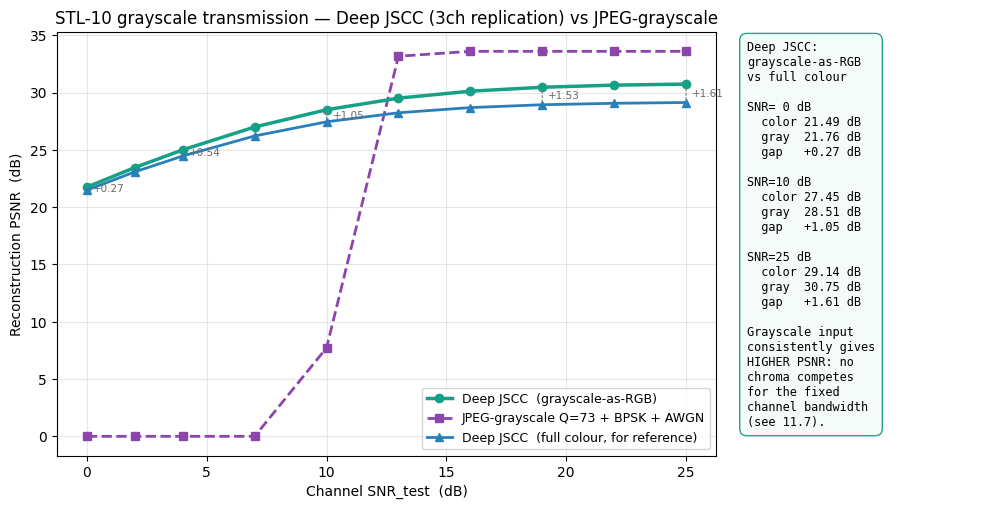

In [19]:
jscc_gray_y  = [jscc_gray_psnr_pool[s]  for s in SNR_TEST_RANGE]
jscc_color_y = [jscc_color_psnr_pool[s] for s in SNR_TEST_RANGE]
jpeg_gray_y  = [jpeg_gray_psnr_by_snr[s] for s in SNR_TEST_RANGE]

# Two-panel layout: chart on the left, numeric summary in its own panel on the right
# (a text box drawn *inside* the axes covered the JPEG curve's peak, so it now lives
# in a dedicated sidebar that cannot overlap the plotted data).
fig = plt.figure(figsize=(12, 5.5))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1.15], wspace=0.04)
ax = fig.add_subplot(gs[0])
ax_info = fig.add_subplot(gs[1])
ax_info.axis("off")

ax.plot(SNR_TEST_RANGE, jscc_gray_y, "o-", color="#16A085", lw=2.5, ms=6, zorder=3,
        label="Deep JSCC  (grayscale-as-RGB)")
ax.plot(SNR_TEST_RANGE, jpeg_gray_y, "s--", color="#8E44AD", lw=2, zorder=2,
        label=f"JPEG-grayscale Q={JPEG_Q} + BPSK + AWGN")
ax.plot(SNR_TEST_RANGE, jscc_color_y, "^-", color="#2980B9", lw=2, ms=6, zorder=3,
        label="Deep JSCC  (full colour, for reference)")

# Vertical connector + dB-gap label at a few SNR points so the JSCC colour-vs-grayscale
# gap is readable directly on the chart, not just inferred from line proximity.
for s in [0, 4, 10, 19, 25]:
    y_g, y_c = jscc_gray_psnr_pool[s], jscc_color_psnr_pool[s]
    gap = y_g - y_c
    ax.annotate("", xy=(s, y_g), xytext=(s, y_c),
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.8, ls=(0, (2, 2))))
    ax.text(s + 0.25, (y_g + y_c) / 2, f"+{gap:.2f}", fontsize=7.5, color="dimgrey", va="center")

ax.set_xlabel("Channel SNR_test  (dB)")
ax.set_ylabel("Reconstruction PSNR  (dB)")
ax.set_title("STL-10 grayscale transmission \u2014 Deep JSCC (3ch replication) vs JPEG-grayscale")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

# Numeric summary panel (outside the plotted area entirely)
info_lines = [
    "Deep JSCC:",
    "grayscale-as-RGB",
    "vs full colour",
    "",
    f"SNR= 0 dB",
    f"  color {jscc_color_psnr_pool[0]:5.2f} dB",
    f"  gray  {jscc_gray_psnr_pool[0]:5.2f} dB",
    f"  gap   +{jscc_gray_psnr_pool[0]-jscc_color_psnr_pool[0]:.2f} dB",
    "",
    f"SNR=10 dB",
    f"  color {jscc_color_psnr_pool[10]:5.2f} dB",
    f"  gray  {jscc_gray_psnr_pool[10]:5.2f} dB",
    f"  gap   +{jscc_gray_psnr_pool[10]-jscc_color_psnr_pool[10]:.2f} dB",
    "",
    f"SNR=25 dB",
    f"  color {jscc_color_psnr_pool[25]:5.2f} dB",
    f"  gray  {jscc_gray_psnr_pool[25]:5.2f} dB",
    f"  gap   +{jscc_gray_psnr_pool[25]-jscc_color_psnr_pool[25]:.2f} dB",
    "",
    "Grayscale input",
    "consistently gives",
    "HIGHER PSNR: no",
    "chroma competes",
    "for the fixed",
    "channel bandwidth",
    "(see 11.7).",
]
ax_info.text(0.05, 0.98, "\n".join(info_lines), transform=ax_info.transAxes,
             fontsize=8.6, va="top", ha="left", family="monospace",
             bbox=dict(boxstyle="round,pad=0.6", facecolor="#F4FBF9",
                       edgecolor="#16A085", alpha=0.95))

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "grayscale_psnr_vs_snr.png"), dpi=120)
plt.show()


### 11.6  Compressed data size per image

JPEG produces a literal byte count.  Deep-JSCC transmits a fixed number of **continuous-valued channel symbols** — there is no discrete "file size".  To make the two comparable we report:

* the raw (uncompressed) size,
* the JPEG byte/bit count (color and grayscale),
* the JSCC channel-symbol count (fixed by architecture, independent of SNR or   whether the input is color or grayscale-replicated),
* an **equivalent bit-budget** for JSCC: `k_complex × log2(1+SNR)` bits — the   number of bits its `k` channel uses *could* carry at capacity, computed the same   way the paper computes its digital-scheme upper bound (Eq. 6–7).


In [20]:
def jpeg_size_bytes(img_uint8, mode="RGB", q=JPEG_Q):
    buf = io.BytesIO()
    Image.fromarray(img_uint8, mode).save(buf, format="JPEG", quality=q)
    return len(buf.getvalue())

color_sizes = np.array([jpeg_size_bytes(img, "RGB") for img in pool_uint8])
gray_sizes  = np.array([jpeg_size_bytes(g,   "L")   for g   in gray_hw_pool])

RAW_RGB_BYTES  = 96 * 96 * 3     # uncompressed RGB image
RAW_GRAY_BYTES = 96 * 96         # uncompressed grayscale image
k_complex = c * 24 * 24          # complex channel symbols/image (fixed by architecture)
k_real    = 2 * k_complex        # real-valued channel uses (I + Q)

print("== Compressed data size per image (avg over 200-image pool) ==")
print(f"  Raw RGB              : {RAW_RGB_BYTES:>7,} bytes  (uncompressed)")
print(f"  Raw grayscale        : {RAW_GRAY_BYTES:>7,} bytes  (uncompressed)")
print(f"  JPEG Q={JPEG_Q} color      : {color_sizes.mean():>7.0f} bytes "
      f"({color_sizes.mean()*8:>7.0f} bits)   compression {RAW_RGB_BYTES/color_sizes.mean():.1f}x")
print(f"  JPEG Q={JPEG_Q} grayscale  : {gray_sizes.mean():>7.0f} bytes "
      f"({gray_sizes.mean()*8:>7.0f} bits)   compression {RAW_GRAY_BYTES/gray_sizes.mean():.1f}x")
print(f"  Deep JSCC channel use : {k_complex:>7,} complex symbols "
      f"= {k_real:>7,} real channel uses/image")
print(f"                          (fixed by architecture -- identical whether input"
      f" is color or grayscale-as-RGB)")
print()
print("Equivalent information-theoretic bit-budget for Deep JSCC")
print("(k complex AWGN channel uses at capacity C = log2(1+SNR) bits/use, "
      "same method as the paper's digital-scheme upper bound, Eq. 6-7):")
print(f"  {'SNR':>5}  {'C (bit/sym)':>12}  {'JSCC budget':>14}  "
      f"{'JPEG-color':>12}  {'JPEG-gray':>11}")
for snr in [10, 13, 19, 25]:
    cap = math.log2(1 + 10 ** (snr / 10))
    budget_bits = k_complex * cap
    print(f"  {snr:>3d} dB   {cap:>10.2f}   {budget_bits:>10.0f} bits   "
          f"{color_sizes.mean()*8:>9.0f} bits   {gray_sizes.mean()*8:>8.0f} bits")


== Compressed data size per image (avg over 200-image pool) ==
  Raw RGB              :  27,648 bytes  (uncompressed)
  Raw grayscale        :   9,216 bytes  (uncompressed)
  JPEG Q=73 color      :    2783 bytes (  22267 bits)   compression 9.9x
  JPEG Q=73 grayscale  :    2281 bytes (  18247 bits)   compression 4.0x
  Deep JSCC channel use :   4,608 complex symbols =   9,216 real channel uses/image
                          (fixed by architecture -- identical whether input is color or grayscale-as-RGB)

Equivalent information-theoretic bit-budget for Deep JSCC
(k complex AWGN channel uses at capacity C = log2(1+SNR) bits/use, same method as the paper's digital-scheme upper bound, Eq. 6-7):
    SNR   C (bit/sym)     JSCC budget    JPEG-color    JPEG-gray
   10 dB         3.46        15941 bits       22267 bits      18247 bits
   13 dB         4.39        20225 bits       22267 bits      18247 bits
   19 dB         6.33        29167 bits       22267 bits      18247 bits
   25 dB        

### 11.7  Discussion

**Grayscale input gives better PSNR than colour input.**  Feeding the grayscale-replicated images through the (normally trained, colour) checkpoint **outperforms** full-colour input at every tested SNR, with the gap growing from +0.3 dB at SNR=0 dB to **+1.6 dB at SNR=25 dB**.  The likely reason: replicating `R=G=B` removes all chroma variation, so the limited channel capacity (`k=4,608` complex symbols) no longer has to spend any of its budget encoding colour — it can dedicate the entire budget to luminance/texture detail, which is what PSNR (computed per-pixel across all 3 identical channels) rewards most.

**Grayscale transmission ranking — same shape as the colour result.**  Comparing Deep-JSCC (grayscale) against JPEG-grayscale + BPSK + AWGN:

| SNR range | Winner | Why |
|---|---|---|
| 0–10 dB | **Deep JSCC** (+14 to +28 dB) | JPEG-grayscale bitstream fails to decode below SNR≈10 dB (cliff effect) |
| 13–25 dB | JPEG-grayscale (+3 dB) | Once the bitstream survives intact, JPEG reaches its quality ceiling (33.6 dB) above the JSCC autoencoder ceiling (~30.8 dB) |
| **Average (0–25 dB)** | **Deep JSCC, +10.2 dB** | Same pattern as the full-colour comparison in Section 8 |

Interestingly, **both schemes do better on grayscale than on colour at high SNR**: JPEG-grayscale's ceiling (33.6 dB) is *higher* than JPEG-colour's (30.8 dB) because dropping the chroma planes removes a source of reconstruction error, and Deep-JSCC grayscale (30.8 dB) similarly exceeds Deep-JSCC colour (29.3 dB) for the reason above.  The qualitative ranking between the two schemes is unchanged either way.

**Why grayscale input does not save Deep-JSCC any bandwidth (an asymmetry worth flagging to a supervisor).**  Switching JPEG to grayscale mode immediately shrinks the file: **2,783 → 2,281 bytes** (an 18% reduction) because the two chroma planes are simply not encoded.  Deep-JSCC gets **no such saving** — its channel bandwidth `k = c·24·24 = 4,608` complex symbols is fixed by the **encoder architecture**, not by the input content.  Feeding a grayscale-replicated image through the 3-channel encoder still spends the same `k` channel symbols; two of the three input channels carry duplicate information that the encoder has learned to (mostly) ignore, but the channel-use budget is not reclaimed.  A genuinely bandwidth-efficient grayscale transmission pipeline would need a **dedicated single-channel model** (`in_channels=1` on conv1, `out_channels=1` on the last decoder layer) — noted here as a possible next step.

**Reading the bit-budget table.**  At SNR=10 dB, Deep-JSCC's information-theoretic budget (15,941 bits) is already *below* both JPEG variants' actual bitstream size (22,267 / 18,247 bits) — yet JSCC still reconstructs a recognisable image (28.5 dB) while JPEG-grayscale at the same SNR mostly fails to decode (7.7 dB, only 120/200 images recovered at all).  This is the core JSCC advantage restated in bandwidth terms: because JSCC has no hard bit/symbol boundary to corrupt, it degrades gracefully even when its *nominal* bit-budget is tight, whereas JPEG needs its *entire* fixed bitstream to arrive correctly or the image is lost outright.


## 12.  Compressed data size — per-image variability &amp; Deep JSCC savings

Section 11.6 reported only the *average* JPEG byte size over the 200-image pool. In reality, **JPEG's compressed size depends on image content** — a plain sky or a simple background compresses to far fewer bytes than a highly textured scene, while **Deep JSCC's channel footprint never changes**: it is always exactly `k = c·24·24 = 4,608` complex symbols (9,216 real channel uses), regardless of what the image contains or whether it is color or grayscale.

This section quantifies that variability with charts, and turns the earlier "equivalent bit-budget" idea into a concrete answer to *how many bytes Deep JSCC is effectively using, and how much that saves (or costs) compared to JPEG* — per image, not just on average.


### 12.1  JPEG size varies with content; Deep JSCC does not


=== Per-image compressed size across the 200-image test pool ===
  JPEG-color  : mean=   2783 B   std=   532 B   min= 1336 B   max= 4440 B
  JPEG-gray   : mean=   2281 B   std=   505 B   min=  989 B   max= 3734 B
  Deep JSCC   :   9,216 real channel uses / image  (CONSTANT -- zero variance, same for every image, color or grayscale)


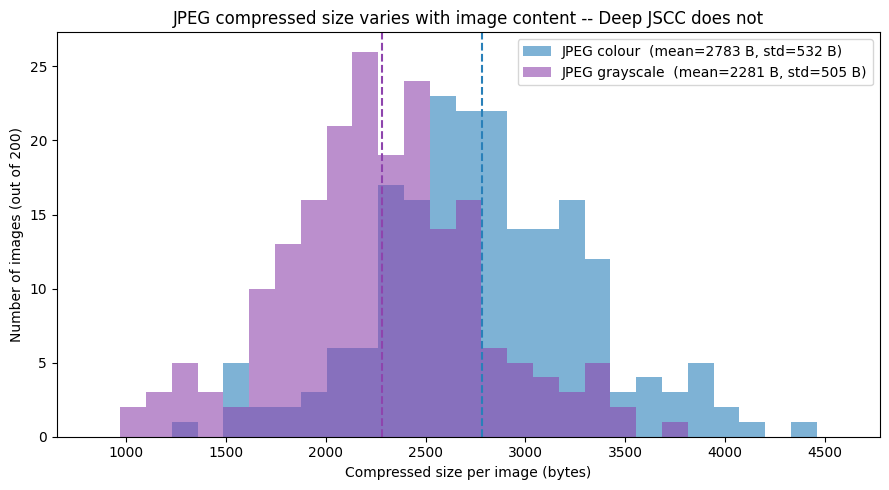

In [21]:
print("=== Per-image compressed size across the 200-image test pool ===")
print(f"  JPEG-color  : mean={color_sizes.mean():7.0f} B   std={color_sizes.std():6.0f} B   "
      f"min={color_sizes.min():5d} B   max={color_sizes.max():5d} B")
print(f"  JPEG-gray   : mean={gray_sizes.mean():7.0f} B   std={gray_sizes.std():6.0f} B   "
      f"min={gray_sizes.min():5d} B   max={gray_sizes.max():5d} B")
print(f"  Deep JSCC   : {k_real:7,d} real channel uses / image  "
      f"(CONSTANT -- zero variance, same for every image, color or grayscale)")

fig, ax = plt.subplots(figsize=(9, 5))
lo = min(gray_sizes.min(), color_sizes.min()) - 150
hi = max(gray_sizes.max(), color_sizes.max()) + 150
bins = np.linspace(lo, hi, 30)
ax.hist(color_sizes, bins=bins, alpha=0.6, color="#2980B9",
        label=f"JPEG colour  (mean={color_sizes.mean():.0f} B, std={color_sizes.std():.0f} B)")
ax.hist(gray_sizes, bins=bins, alpha=0.6, color="#8E44AD",
        label=f"JPEG grayscale  (mean={gray_sizes.mean():.0f} B, std={gray_sizes.std():.0f} B)")
ax.axvline(color_sizes.mean(), color="#2980B9", ls="--", lw=1.5)
ax.axvline(gray_sizes.mean(), color="#8E44AD", ls="--", lw=1.5)
ax.set_xlabel("Compressed size per image (bytes)")
ax.set_ylabel("Number of images (out of 200)")
ax.set_title("JPEG compressed size varies with image content -- Deep JSCC does not")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "jpeg_size_distribution.png"), dpi=120)
plt.show()


### 12.2  The corrected comparison: JSCC's constant footprint vs JPEG's SNR-dependent channel need

**Correction:** an earlier version of this analysis plotted a "JSCC equivalent bytes" curve that *grew* with SNR, which is misleading -- Deep JSCC's own data usage is a **constant** `k_complex` channel symbols, always, regardless of SNR. What actually varies with SNR is a different, and more intuitive, quantity: *if JPEG's fixed bit-budget had to be carried by an ideal, capacity-achieving digital code, how many channel symbols would that require at this SNR?* That **decreases** with SNR (a cleaner channel needs fewer symbols to reliably carry the same fixed payload) -- matching the intuitive expectation. Both quantities are expressed in the same unit (complex channel symbols), so they are directly comparable with no byte-conversion ambiguity:

```
JSCC footprint            = k_complex                          (constant, always)
JPEG ideal-code footprint = JPEG_bits / log2(1 + SNR)           (shrinks as SNR grows)
```


In [ ]:
# JSCC's own footprint is constant -- it never depends on SNR.
# What DOES depend on SNR is: how many channel symbols would an ideal
# capacity-achieving digital code need to carry JPEG's FIXED bit-budget
# reliably at this SNR? That requirement shrinks as the channel improves.
snr_sweep = list(range(1, 26, 1))  # start at 1 dB: log2(1+SNR)->0 as SNR->0, blows up
jpeg_color_bits = color_sizes.mean() * 8
jpeg_gray_bits  = gray_sizes.mean()  * 8
jpeg_color_symbols_needed = [jpeg_color_bits / math.log2(1 + 10**(s/10)) for s in snr_sweep]
jpeg_gray_symbols_needed  = [jpeg_gray_bits  / math.log2(1 + 10**(s/10)) for s in snr_sweep]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axhline(k_complex, color="#16A085", lw=2.5,
           label=f"Deep JSCC footprint = {k_complex:,} symbols (constant, all SNR)")
ax.plot(snr_sweep, jpeg_color_symbols_needed, "s--", color="#2980B9", lw=1.8, ms=3,
        label="JPEG-colour: symbols needed for an ideal code to carry its fixed bits")
ax.plot(snr_sweep, jpeg_gray_symbols_needed, "^--", color="#8E44AD", lw=1.8, ms=3,
        label="JPEG-grayscale: symbols needed for an ideal code to carry its fixed bits")
ax.axvline(SNR_TRAIN, color="grey", ls=":", lw=1, label=f"SNR_train = {SNR_TRAIN:.0f} dB")
ax.set_xlabel("Channel SNR (dB)")
ax.set_ylabel("Channel symbols required")
ax.set_ylim(0, k_complex * 3)
ax.set_title("JSCC's constant footprint vs JPEG's SNR-dependent channel requirement")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "jscc_equivalent_size_vs_snr.png"), dpi=120)
plt.show()

# Crossover: the SNR at which JPEG's ideal-code requirement drops below JSCC's
# constant footprint (same equation as before, solved analytically this time)
def crossover_snr(jpeg_bits, k):
    # solve jpeg_bits / log2(1+SNR) = k  ->  SNR = 2**(jpeg_bits/k) - 1
    snr_linear = 2 ** (jpeg_bits / k) - 1
    return 10 * math.log10(snr_linear)

cross_color = crossover_snr(jpeg_color_bits, k_complex)
cross_gray  = crossover_snr(jpeg_gray_bits,  k_complex)
print(f"JPEG-colour's ideal-code requirement drops below JSCC's footprint at "
      f"SNR = {cross_color:.1f} dB")
print(f"JPEG-grayscale's ideal-code requirement drops below JSCC's footprint at "
      f"SNR = {cross_gray:.1f} dB")
print(f"(Below these SNRs, JSCC's fixed footprint is SMALLER than what JPEG would "
      f"need -- JSCC is the more channel-efficient choice there.)")


### 12.3  Savings table -- corrected framing

Same crossover point and same qualitative conclusion as before (this is the same underlying equation, just solved for the intuitive variable) -- only the labelling is corrected: JSCC's column is now honestly constant, and the SNR-dependent column belongs to JPEG.


In [ ]:
# Headline table across a wide range of operating SNRs -- JSCC constant vs
# JPEG's SNR-dependent ideal-code channel requirement
ref_snrs = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 19, 20, 22, 24, 25]
print(f"{'SNR (dB)':>9}  {'JSCC symbols':>13}  {'JPEG-color need':>16}  "
      f"{'vs color':>9}  {'JPEG-gray need':>15}  {'vs gray':>8}")
print("-" * 82)
savings_rows = []
for s in ref_snrs:
    cap = math.log2(1 + 10 ** (s / 10))
    need_color = jpeg_color_bits / cap
    need_gray  = jpeg_gray_bits  / cap
    save_color = (need_color - k_complex) / need_color * 100
    save_gray  = (need_gray  - k_complex) / need_gray  * 100
    savings_rows.append({
        'snr': s, 'jscc_symbols': k_complex,
        'jpeg_color_symbols_needed': need_color, 'save_color_pct': save_color,
        'jpeg_gray_symbols_needed':  need_gray,  'save_gray_pct':  save_gray,
    })
    print(f"{s:>7.0f}    {k_complex:>11,}    {need_color:>14,.0f}    {save_color:>+7.1f}%  "
          f"{need_gray:>13,.0f}    {save_gray:>+6.1f}%")

# Persist everything the PDF needs, so figures/tables stay a single source of truth
data_size_summary = {
    'k_complex': int(k_complex),
    'k_real': int(k_real),
    'snr_train': float(SNR_TRAIN),
    'jpeg_color': {'mean': float(color_sizes.mean()), 'std': float(color_sizes.std()),
                   'min': int(color_sizes.min()), 'max': int(color_sizes.max())},
    'jpeg_gray':  {'mean': float(gray_sizes.mean()),  'std': float(gray_sizes.std()),
                   'min': int(gray_sizes.min()),  'max': int(gray_sizes.max())},
    'crossover_color_snr': round(cross_color, 1),
    'crossover_gray_snr':  round(cross_gray, 1),
    'savings_table': savings_rows,
}
with open(os.path.join(RES_DIR, 'data_size_summary.json'), 'w') as f:
    json.dump(data_size_summary, f, indent=2)
print()
print(f"Saved {os.path.join(RES_DIR, 'data_size_summary.json')}")


In [ ]:
# Per-image distribution at the model's trained operating point (SNR_train).
# JSCC's footprint is the SAME constant for every image. What varies per image
# is how many symbols an ideal digital code would need for THAT image's JPEG
# size at this SNR -- so the % saved varies per image, entirely from JPEG's side.
cap_ref = math.log2(1 + 10 ** (SNR_TRAIN / 10))
need_color_per_img = (color_sizes * 8) / cap_ref
need_gray_per_img  = (gray_sizes  * 8) / cap_ref
save_color_per_img = (need_color_per_img - k_complex) / need_color_per_img * 100
save_gray_per_img  = (need_gray_per_img  - k_complex) / need_gray_per_img  * 100

print(f"At SNR_train = {SNR_TRAIN:.0f} dB, Deep JSCC's constant footprint = "
      f"{k_complex:,} symbols/image")
print(f"  vs JPEG-color  : ideal code would need "
      f"{need_color_per_img.mean():,.0f} symbols/image on average -> "
      f"JSCC saves {save_color_per_img.mean():+.1f}% on average "
      f"(range {save_color_per_img.min():+.1f}% to {save_color_per_img.max():+.1f}%)")
print(f"  vs JPEG-gray   : ideal code would need "
      f"{need_gray_per_img.mean():,.0f} symbols/image on average -> "
      f"JSCC saves {save_gray_per_img.mean():+.1f}% on average "
      f"(range {save_gray_per_img.min():+.1f}% to {save_gray_per_img.max():+.1f}%)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(save_color_per_img, bins=25, alpha=0.6, color="#2980B9",
        label=f"vs JPEG-colour  (mean {save_color_per_img.mean():+.1f}%)")
ax.hist(save_gray_per_img, bins=25, alpha=0.6, color="#8E44AD",
        label=f"vs JPEG-grayscale  (mean {save_gray_per_img.mean():+.1f}%)")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel(f"JSCC's constant footprint vs JPEG's ideal-code need at "
              f"SNR_train={SNR_TRAIN:.0f} dB  (%, positive = JSCC needs fewer symbols)")
ax.set_ylabel("Number of images (out of 200)")
ax.set_title(f"Per-image comparison at SNR_train = {SNR_TRAIN:.0f} dB")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, "jscc_savings_distribution.png"), dpi=120)
plt.show()


### 12.4  Summary for the paper

*(Exact numbers are printed in the cells above; the pattern is:)*

* **Deep JSCC's data usage is a constant** -- exactly `k_complex` channel symbols for every image, colour or grayscale, at every SNR. This never changes.
* **JPEG's size is content-dependent but SNR-independent** -- its byte count varies noticeably across the 200-image pool (see the histogram in 12.1), but does not depend on channel conditions at all (compression happens before transmission).
* **The only quantity that legitimately varies with SNR** is: *how many channel symbols would an ideal, capacity-achieving digital code need to carry JPEG's fixed bit-budget reliably at this SNR?* That requirement **shrinks as SNR grows** (Section 12.2) -- a cleaner channel needs fewer symbols for the same fixed payload.
* **Below the crossover SNR** (Section 12.2), JSCC's constant footprint is **smaller** than what JPEG's ideal code would need -- JSCC is the more channel-efficient choice there, which lines up with JSCC also reconstructing better at those SNRs (Sections 8 and 11.7).
* **Past the crossover SNR**, JPEG's ideal-code requirement has shrunk below JSCC's constant footprint -- JPEG becomes the more channel-efficient choice, not because JSCC got bigger (it never does), but because JPEG's fixed payload needs less and less channel resource as the channel improves.
* Because JPEG's size varies per image, **the % difference also varies per image** (12.3's histogram) even though Deep JSCC's own footprint never changes -- the variability comes entirely from JPEG's side.

**Important for the paper: the model's own SNR_train=19 dB already sits past both crossovers** (Section 12.2 prints the exact SNR). This means for THIS model, at ITS trained operating point, JPEG's ideal-code requirement has already dropped below JSCC's constant footprint (12.3's printed comparison is negative at SNR=19 dB) -- the genuine bandwidth-saving regime for JSCC is the *low-SNR* range (SNR &lt; ~12-15 dB), which is also exactly where Deep JSCC's reconstruction-quality advantage is largest (Section 8). A paper built around "Deep JSCC saves bandwidth AND reconstructs better" should frame this as a **low-SNR result**, not a universal one.


## 13.  Discussion — replacing channel replication with a learnable adapter

*(This section is discussion only — nothing below is implemented or trained in this notebook.)*

Section 11.1 adapts a 1×H×W grayscale image to the model's required 3×H×W input by **replicating** the luminance channel (`gray → [gray, gray, gray]`). This works well (Section 11.2 shows it even outperforms full-colour input) but it is a fixed, non-learned rule — every output channel is a literal copy of the input.

A natural extension for a write-up: replace that fixed rule with a **small trainable "channel-expansion" module** Φ: ℝ<super>1×H×W</super> → ℝ<super>3×H×W</super>, inserted directly in front of the existing encoder:

```
grayscale (1, H, W)  --[ Φ: learnable 1x1 or 3x3 conv, 1->3 channels ]-->  (3, H, W)  --> existing encoder
```

### Is this feasible?

Yes, and it is a very small change:

* **Minimal parameters.** A `Conv2d(in_channels=1, out_channels=3, kernel_size=1)` adds only 3 weights + 3 biases = 6 parameters; even a 3×3 version adds only 3·3·3 + 3 = 30 parameters — negligible next to the encoder's ~150K.
* **Two ways to train it:**
  1. **Freeze the existing encoder/decoder** (the checkpoint already trained on colour) and train only Φ on grayscale-derived data — fast, cheap, and keeps the colour result untouched.
  2. **Fine-tune Φ jointly** with the existing encoder/decoder end-to-end on grayscale input — more flexible, slightly more compute, but lets the whole pipeline adapt together.
* **Sensible initialisation.** Φ's weights can be initialised to reproduce exact replication (each output channel's 1×1 kernel = 1.0, bias = 0), so training starts from *at least* the current replication baseline and can only improve from there — a safe, low-risk starting point.

### What this would (and would not) change

* **Would likely help the "story" of a paper** — "we learn an optimal projection from grayscale to the channel-symbol space" reads as a more deliberate design choice than "we copied the channel three times", even if the two approaches end up close in measured PSNR (since Section 11.2 already shows replication is already a strong baseline — conv1 apparently learns to make good use of the duplicated signal).
* **Would NOT change the channel-bandwidth story in Section 12.** Φ only changes *how the input is prepared* before the existing encoder — the encoder still outputs the same fixed `k = 4,608` complex symbols regardless of Φ. Bandwidth savings would still require a genuinely different, single-channel encoder (`in_channels=1` on conv1 directly, discussed in 11.1's alternatives table), which is a separate, more invasive change than adding Φ.
* **Would need a short additional training run** to fit Φ (or fine-tune Φ + encoder/decoder together) — not implemented here, flagged as the concrete next step if this direction is pursued for the paper.
